# NLP sobre comentarios de anuncios — coches.net

**TFG — Ingeniería de Datos | Módulo de Procesamiento de Lenguaje Natural**

Extracción de features estructuradas a partir del campo `comments` de los anuncios.
El corpus se enriquece con la segmentación **Utilitario · Plus · Premium** del pipeline ML
(`ml_coches.ipynb`) para analizar diferencias lingüísticas entre segmentos.

| Sección | Contenido |
|---------|-----------|
| 1 | Carga, merge con anuncios y exploración del corpus |
| 2 | Distribución de comentarios por segmento |
| 3 | Tokenización y TF-IDF (global + diferencial por segmento) |
| 4 | Topic Modeling LDA — selección de K y análisis de topics |
| 5 | Extracción de features regex — cobertura global y por segmento |
| 6 | Impacto de features en el precio por segmento |
| 7 | Integración y exportación del Feature Store |

> **Convención:** `CSV_PATH = 'anuncios.csv'` y `COMMENTS_PATH = 'comments.csv'` junto al notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import json
import numpy  as np
import pandas as pd
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn as sns

# ── Configuración global ────────────────────────────────────────────────
RANDOM_SEED    = 42
CSV_PATH       = 'anuncios.csv'
COMMENTS_PATH  = 'comments.csv'

os.makedirs('IMG', exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi':120, 'axes.titlesize':13,
                     'axes.titleweight':'bold', 'axes.labelsize':11})

SEG_ORDER  = ['Utilitario', 'Plus', 'Premium']
SEG_COLORS = {'Utilitario':'#2196F3', 'Plus':'#FF9800', 'Premium':'#9C27B0'}

# ── Constantes de segmentación (idénticas a ml_coches.ipynb) ───────────
MARCAS_PREMIUM = {
    "FERRARI","LAMBORGHINI","BENTLEY","ASTON MARTIN","MASERATI",
    "BUGATTI","ROLLS-ROYCE","LOTUS","MCLAREN",
}
MARCAS_PLUS = {
    "BMW","MERCEDES-BENZ","AUDI","PORSCHE","LEXUS","JAGUAR",
    "LAND-ROVER","ALFA ROMEO","VOLVO","MINI","TESLA","DS",
    "ALPINE","CADILLAC","CORVETTE",
}

def asignar_segmento(brand, price, umbral_premium):
    b = str(brand).upper().strip() if pd.notna(brand) else ""
    p = price if pd.notna(price) else 0
    if b in MARCAS_PREMIUM or p > umbral_premium: return "Premium"
    if b in MARCAS_PLUS:                          return "Plus"
    return "Utilitario"

print("Imports OK")


Imports OK


## 1. Carga, Merge y Exploración del Corpus

Se carga `comments.csv` (solo `id` + `comments`) y se une con `anuncios.csv` para
incorporar `segmento`, `price`, `brand`, `fuel` y `year`. Esto habilita todo el análisis
diferencial por segmento que el notebook original no podía realizar.

In [2]:
# ── Cargar CSV de comentarios ───────────────────────────────────────────
df_raw = pd.read_csv(COMMENTS_PATH)
if df_raw.columns[0] == 'Unnamed: 0':
    df_raw = df_raw.drop(columns=df_raw.columns[0])

# ── Cargar anuncios y calcular segmentación ─────────────────────────────
df_anuncios = pd.read_csv(CSV_PATH)
if df_anuncios.columns[0] == 'Unnamed: 0':
    df_anuncios = df_anuncios.drop(columns=df_anuncios.columns[0])

umbral_premium = df_anuncios['price'].quantile(0.97)
df_anuncios['segmento'] = df_anuncios.apply(
    lambda r: asignar_segmento(r['brand'], r['price'], umbral_premium), axis=1
)

# ── Merge: enriquecer comments con metadatos ────────────────────────────
META_COLS = ['id', 'segmento', 'price', 'brand', 'fuel', 'year', 'km']
df = df_raw.merge(df_anuncios[META_COLS], on='id', how='left')

# Corpus con comentario disponible
df_c = df.dropna(subset=['comments']).copy()

print(f"Umbral Premium (P97): {umbral_premium:,.0f} €")
print(f"Total anuncios       : {len(df):,}")
print(f"Con comentario       : {len(df_c):,}  ({len(df_c)/len(df)*100:.1f}%)")
print(f"Sin comentario       : {len(df)-len(df_c):,}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")


Umbral Premium (P97): 57,500 €
Total anuncios       : 25,048
Con comentario       : 24,453  (97.6%)
Sin comentario       : 595

Columnas disponibles: ['id', 'comments', 'segmento', 'price', 'brand', 'fuel', 'year', 'km']


Longitud (chars): mediana=806  media=992  max=3000
Palabras:         mediana=121    media=151    max=525


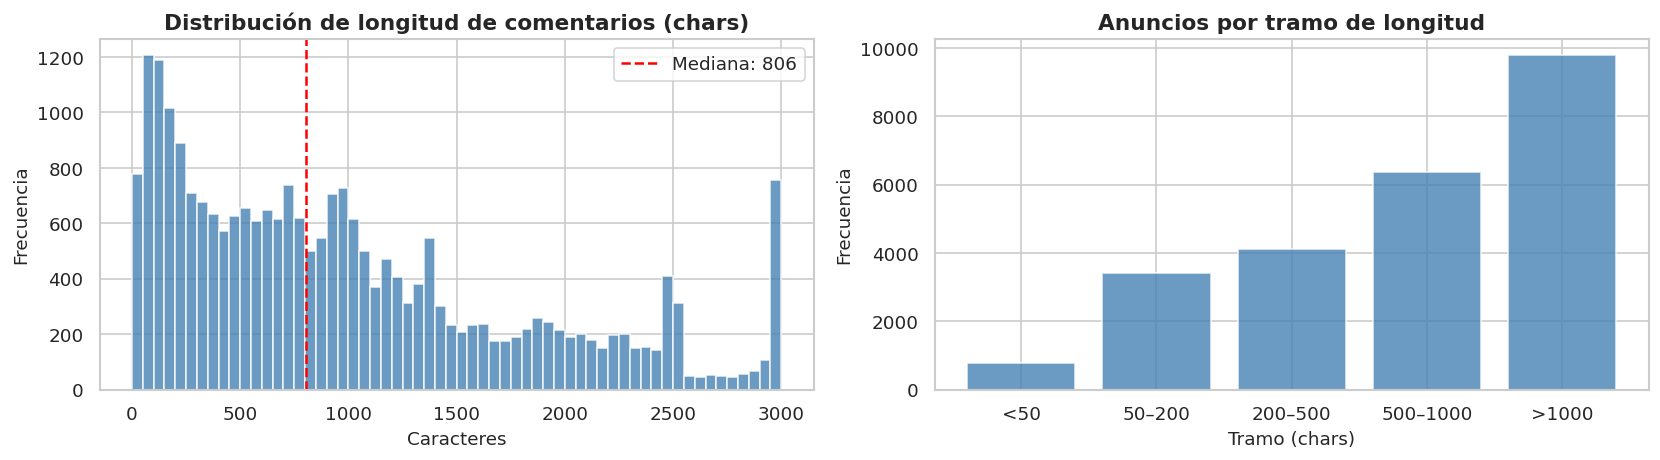

In [3]:
# ── Estadísticas básicas del corpus ────────────────────────────────────
lengths = df_c['comments'].str.len()
words   = df_c['comments'].str.split().str.len()

print(f"Longitud (chars): mediana={lengths.median():.0f}  media={lengths.mean():.0f}  max={lengths.max()}")
print(f"Palabras:         mediana={words.median():.0f}    media={words.mean():.0f}    max={words.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lengths, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(lengths.median(), color='red', linestyle='--',
                label=f'Mediana: {lengths.median():.0f}')
axes[0].set_title('Distribución de longitud de comentarios (chars)')
axes[0].set_xlabel('Caracteres'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

bins_cat = [0, 50, 200, 500, 1000, 9999]
labels_c = ['<50', '50–200', '200–500', '500–1000', '>1000']
counts   = pd.cut(lengths, bins=bins_cat, labels=labels_c).value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Anuncios por tramo de longitud')
axes[1].set_xlabel('Tramo (chars)'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('IMG/plot_cobertura.png', bbox_inches='tight')
plt.show()


## 2. Distribución de Comentarios por Segmento

Análisis de la cobertura y extensión de los comentarios desglosado por segmento de mercado.
Un comentario más largo y detallado puede ser indicativo del tipo de vendedor (particular
elaborado vs. concesionario con plantilla) y del segmento de precio del vehículo.

            total  con_comment   pct
segmento                            
Utilitario  16339        15976  97.8
Plus         7952         7736  97.3
Premium       757          741  97.9


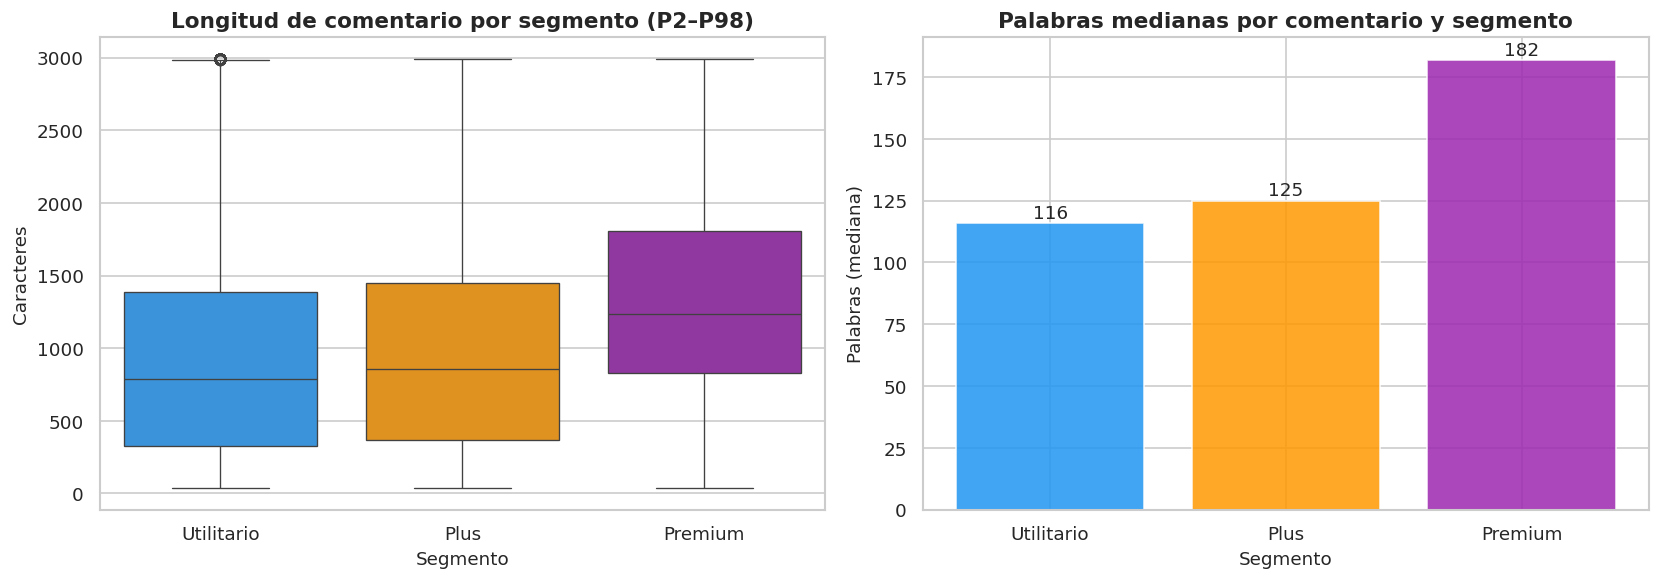

In [4]:
# ── Cobertura por segmento ──────────────────────────────────────────────
cob = df.groupby('segmento').agg(
    total        = ('id',       'count'),
    con_comment  = ('comments', lambda x: x.notna().sum()),
).loc[SEG_ORDER]
cob['pct'] = (cob['con_comment'] / cob['total'] * 100).round(1)
print(cob.to_string())

# ── Longitud mediana por segmento ───────────────────────────────────────
df_c['comment_len']   = df_c['comments'].str.len()
df_c['comment_words'] = df_c['comments'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot longitud por segmento (P2-P98)
df_box = df_c.copy()
lo, hi = df_box['comment_len'].quantile(0.02), df_box['comment_len'].quantile(0.98)
df_box = df_box[(df_box['comment_len'] >= lo) & (df_box['comment_len'] <= hi)]

sns.boxplot(data=df_box, x='segmento', y='comment_len',
            order=SEG_ORDER, palette=SEG_COLORS, ax=axes[0], linewidth=0.8)
axes[0].set_title('Longitud de comentario por segmento (P2–P98)')
axes[0].set_xlabel('Segmento'); axes[0].set_ylabel('Caracteres')

# Mediana de palabras por segmento
med_words = df_c.groupby('segmento')['comment_words'].median().loc[SEG_ORDER]
bars = axes[1].bar(SEG_ORDER, med_words.values,
                   color=[SEG_COLORS[s] for s in SEG_ORDER], edgecolor='white', alpha=0.85)
for bar, v in zip(bars, med_words.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}', ha='center', fontsize=11)
axes[1].set_title('Palabras medianas por comentario y segmento')
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Palabras (mediana)')

plt.tight_layout()
plt.savefig('IMG/plot_cobertura_segmento.png', bbox_inches='tight')
plt.show()


## 3. Tokenización y TF-IDF

### 3.1 TF-IDF global

TF-IDF (*Term Frequency — Inverse Document Frequency*) pondera la relevancia de cada
término en el corpus: alta si el término aparece mucho en pocos documentos, baja si
aparece en casi todos. Los bigramas (`ngram_range=(1,2)`) capturan expresiones como
*"itv pasada"* o *"precio negociable"* que un análisis de unigramas perdería.

In [5]:
# ── Stopwords en español (sin dependencia de NLTK) ─────────────────────
STOPWORDS_ES = list(set([
    'a','al','algo','algunas','algunos','ante','antes','como','con','contra',
    'cual','cuando','de','del','desde','donde','durante','e','el','ella',
    'ellas','ellos','en','entre','era','es','esa','esas','ese','eso','esos',
    'esta','esto','estos','estas','este','estoy','fue','la','las','le','les',
    'lo','los','me','mi','mis','muy','más','nada','ni','no','nos','nosotros',
    'nuestra','nuestro','nuestros','o','os','otra','otros','para','pero','poco','por',
    'porque','que','quien','se','sea','si','sido','siendo','sin','sobre',
    'son','soy','su','sus','también','tanto','te','ti','tiene','tienen',
    'todo','todos','tu','tus','y','ya','yo','él','un','una','unas','uno',
    'unos','hay','hace','han','ser','estar','ver','ir','dar','decir',
    'coche','coches','vendo','vende','vehiculo','vehículo','km','cv','kms',
    'etc','solo','así','aquí','buen','buena','buenos','buenas','bien',
    'año','años','con','por','para','sin','sobre','entre','hasta','desde',
    'su','sus','he','ha','han','has','haya','sea','puede','puedes',
    'contactar','contacte','llame','llama','información','anuncio','precio',
    'vehículos','experiencia','vinculante','contener','errores','auto',
    'ocasión','informativo','contractual','título','oferta','ver',
]))

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b',  ' ', text)
    text = re.sub(r'\s+',        ' ', text)
    return text.strip()

df_c['text_clean'] = df_c['comments'].apply(preprocess)
print(f"Corpus preprocesado: {len(df_c):,} documentos")
print("\nEjemplo original  :", df_c['comments'].iloc[0][:140])
print("Ejemplo procesado :", df_c['text_clean'].iloc[0][:140])


Corpus preprocesado: 24,453 documentos

Ejemplo original  : Ref. 362292
Precio: 17.790 EUR

Tipo de motor: Combustión
Distintivo ambiental: C

Color de pintura:
B4B4 Blanco Candy (sólido)

Color de ta
Ejemplo procesado : ref precio eur tipo de motor combustión distintivo ambiental c color de pintura b4b4 blanco candy sólido color de tapicería p02 marina pack 


Matriz TF-IDF: 24,453 docs × 300 términos


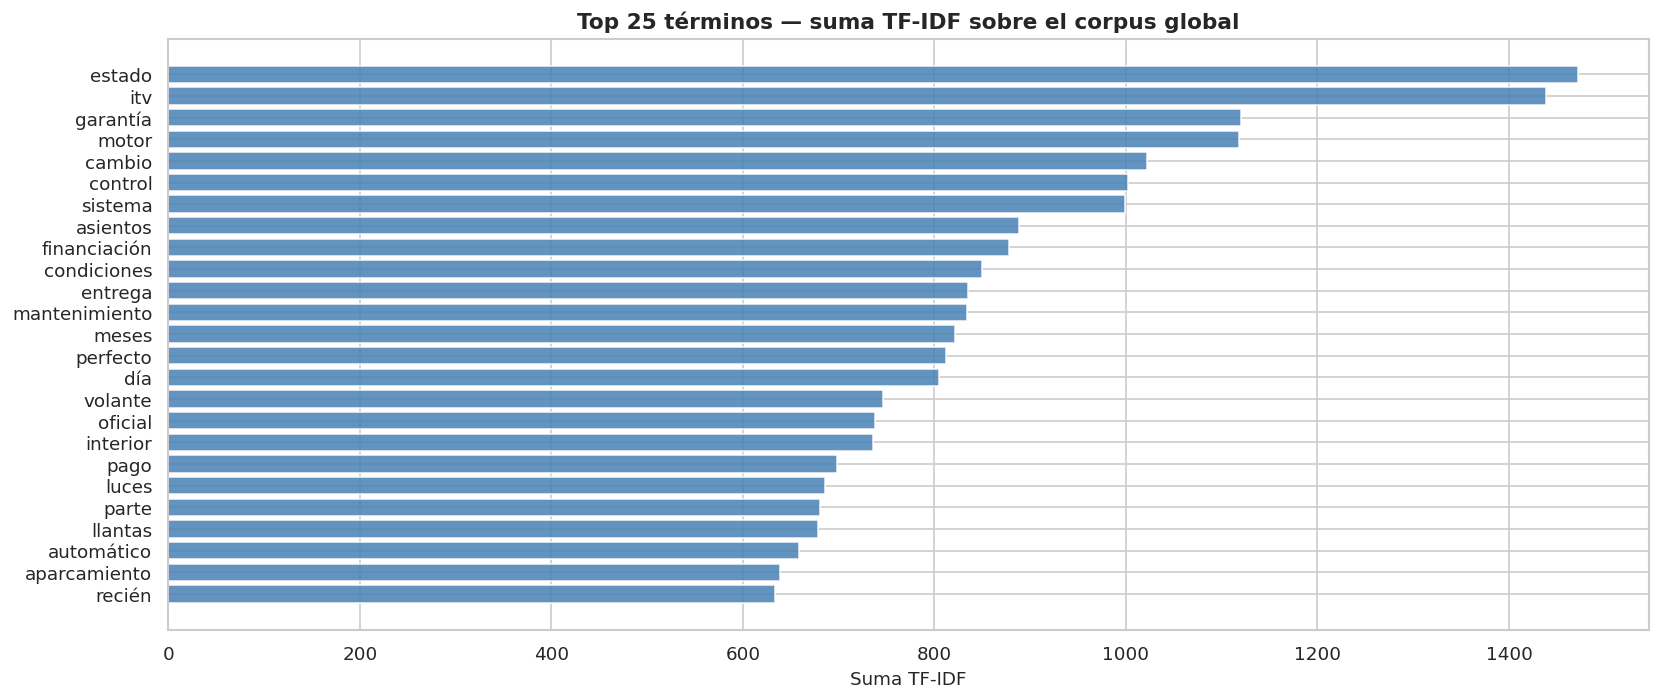

,term,tfidf_sum
0,estado,1472.355387
1,itv,1439.016064
2,garantía,1120.327744
3,motor,1117.644192
4,cambio,1022.086076
5,control,1002.086418
6,sistema,999.291371
7,asientos,888.553456
8,financiación,877.524349
9,condiciones,849.785649


In [6]:
# ── TF-IDF global ───────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=300, ngram_range=(1, 2),
    min_df=15, max_df=0.85, stop_words=STOPWORDS_ES,
)
tfidf_matrix = vectorizer.fit_transform(df_c['text_clean'])
vocab        = vectorizer.get_feature_names_out()

print(f"Matriz TF-IDF: {tfidf_matrix.shape[0]:,} docs × {tfidf_matrix.shape[1]:,} términos")

scores  = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top_idx = scores.argsort()[::-1][:25]
top_terms = pd.DataFrame({'term': vocab[top_idx], 'tfidf_sum': scores[top_idx]})

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top_terms['term'][::-1], top_terms['tfidf_sum'][::-1], color='steelblue', alpha=0.85)
ax.set_title('Top 25 términos — suma TF-IDF sobre el corpus global')
ax.set_xlabel('Suma TF-IDF')
plt.tight_layout()
plt.savefig('IMG/plot_tfidf_top25.png', bbox_inches='tight')
plt.show()
top_terms.head(10)


### 3.2 TF-IDF diferencial por segmento

Se ajusta un vectorizador independiente por segmento para identificar los términos
más relevantes en cada nivel de mercado. Los términos exclusivos de Plus y Premium
revelan diferencias estructurales en el lenguaje de venta.

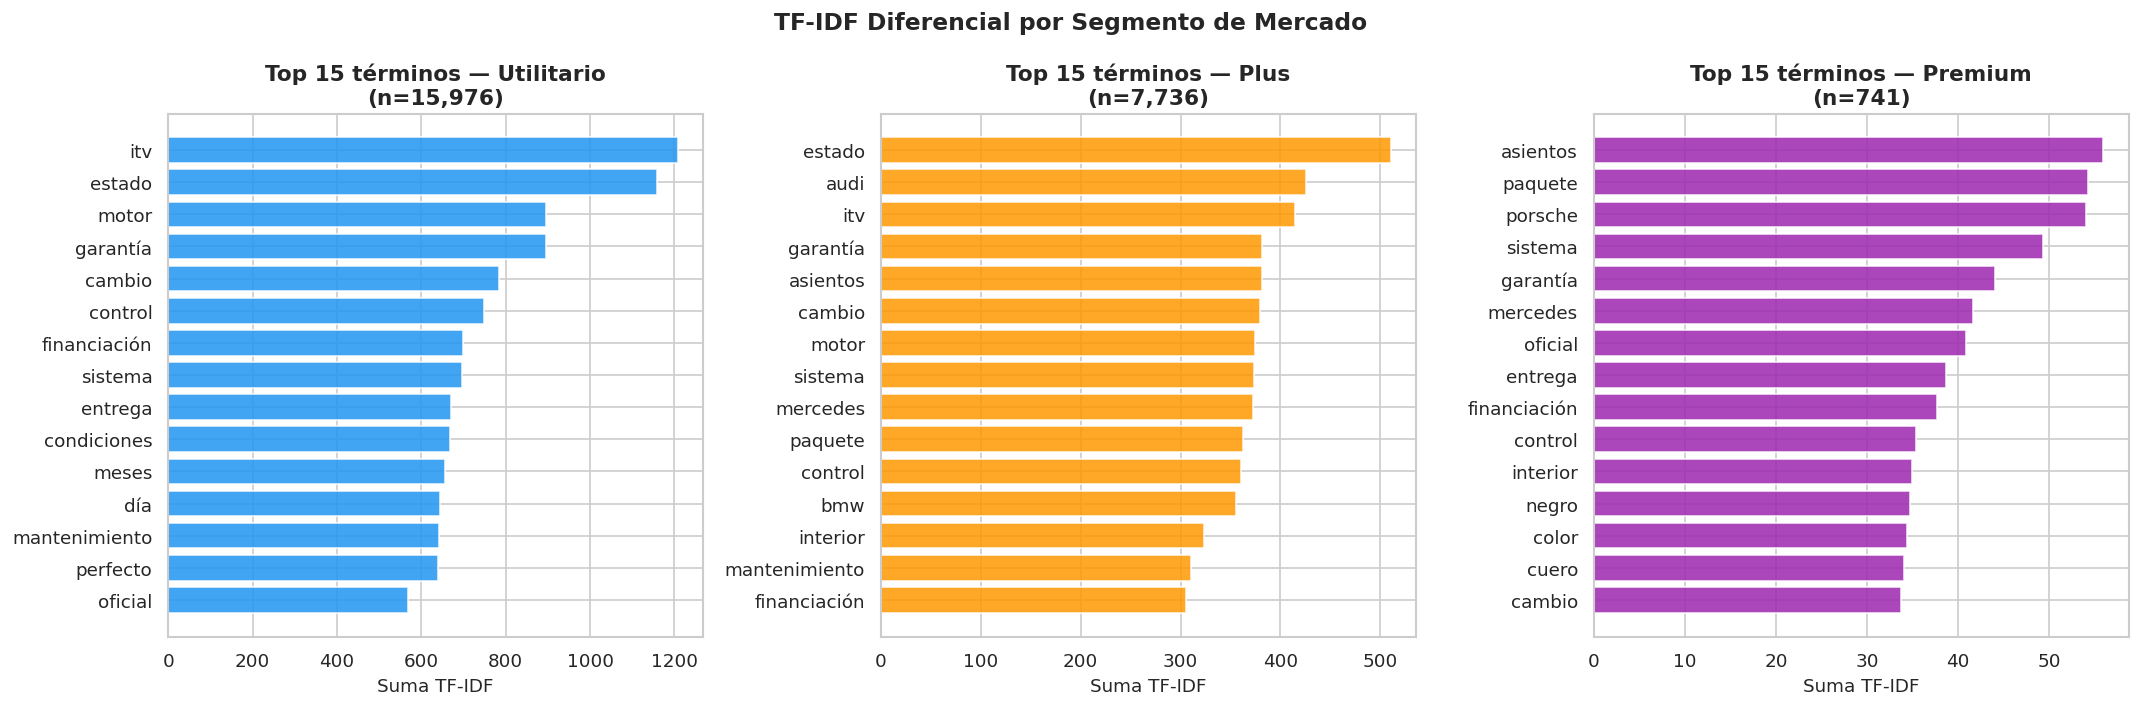

In [7]:
# ── TF-IDF diferencial: top términos únicos por segmento ───────────────
# Justificación: muestra qué vocabulario caracteriza a cada segmento más
# allá de los términos comunes; informa la construcción de features regex.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
N_TERMS = 15

for i, seg in enumerate(SEG_ORDER):
    corpus_seg = df_c[df_c['segmento'] == seg]['text_clean']
    if len(corpus_seg) < 10:
        continue

    vec_seg = TfidfVectorizer(
        max_features=200, ngram_range=(1, 2),
        min_df=5, max_df=0.90, stop_words=STOPWORDS_ES,
    )
    mat_seg = vec_seg.fit_transform(corpus_seg)
    vocab_s  = vec_seg.get_feature_names_out()
    sc       = np.asarray(mat_seg.sum(axis=0)).flatten()
    top_i    = sc.argsort()[::-1][:N_TERMS]

    axes[i].barh(vocab_s[top_i][::-1], sc[top_i][::-1],
                 color=SEG_COLORS[seg], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'Top {N_TERMS} términos — {seg}\n(n={len(corpus_seg):,})')
    axes[i].set_xlabel('Suma TF-IDF')

fig.suptitle('TF-IDF Diferencial por Segmento de Mercado',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('IMG/plot_tfidf_segmentos.png', bbox_inches='tight')
plt.show()


## 4. Topic Modeling LDA

LDA (*Latent Dirichlet Allocation*) agrupa los documentos en **K temas latentes**
sin supervisión. Cada tema es una distribución de probabilidad sobre el vocabulario;
cada documento es una mezcla de temas.

### 4.1 Selección del número óptimo de topics (K)

La **perplexity** mide qué tan bien el modelo probabilístico predice el corpus:
valores más bajos indican mejor ajuste. Se evalúa K desde 2 hasta 20 y se selecciona
el punto de inflexión en la curva (principio del codo).

In [8]:
# ── CountVectorizer para LDA (counts > TF-IDF para modelos de tópicos) ──
count_vec = CountVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=15, max_df=0.85, stop_words=STOPWORDS_ES,
)
count_matrix = count_vec.fit_transform(df_c['text_clean'])
feat_names   = count_vec.get_feature_names_out()
print(f"Matriz de counts: {count_matrix.shape}")

# ── K preseleccionado ──────────────────────────────────────────────────
# La búsqueda por perplexity (K=3..11) sobre muestra de 5.000 documentos
# produjo mejora continua hasta K=11 con pendiente casi plana a partir de K=9.
# Se elige K=9 por equilibrio entre perplexity (99,0) e interpretabilidad.
# Para re-ejecutar la búsqueda descomentar el bloque siguiente:
#
# K_RANGE=range(3,12); perps=[]
# cm_s=count_vec.transform(df_c.sample(5000, random_state=RANDOM_SEED)['text_clean'])
# for k in K_RANGE:
#     m=LatentDirichletAllocation(n_components=k,random_state=RANDOM_SEED,
#                                 max_iter=10,learning_method='online')
#     m.fit(cm_s); perps.append(m.perplexity(cm_s))
#     print(f"  K={k} perp={perps[-1]:.1f}")
# best_k = list(K_RANGE)[int(np.argmin(perps))]

best_k = 9
print(f"K seleccionado: {best_k} (perplexity=99,0 sobre muestra de 5.000 docs)")


Matriz de counts: (24453, 200)
K seleccionado: 9 (perplexity=99,0 sobre muestra de 5.000 docs)


In [9]:
# ── CountVectorizer para LDA (counts > TF-IDF para modelos de tópicos) ──
count_vec = CountVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=15, max_df=0.85, stop_words=STOPWORDS_ES,
)
count_matrix = count_vec.fit_transform(df_c['text_clean'])
feat_names   = count_vec.get_feature_names_out()
print(f"Matriz de counts: {count_matrix.shape}")

# ── Curva de perplexity sobre muestra (5.000 docs) ─────────────────────
# Se usa una muestra para acelerar la búsqueda; 5k docs es suficiente
# para estimar la distribución de topics del corpus completo.
SAMPLE_N = 5000
sample_idx  = df_c.sample(min(SAMPLE_N, len(df_c)), random_state=RANDOM_SEED).index
cm_sample   = count_vec.transform(df_c.loc[sample_idx, 'text_clean'])

K_RANGE      = range(3, 12)
perplexities = []

for k in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=k, random_state=RANDOM_SEED,
        max_iter=10, learning_method='online',
    )
    lda_k.fit(cm_sample)
    perplexities.append(lda_k.perplexity(cm_sample))
    print(f"  K={k:2d}  perplexity={perplexities[-1]:.1f}")

best_k = K_RANGE[int(np.argmin(perplexities))]
print(f"\nK con menor perplexity: {best_k}")


Matriz de counts: (24453, 200)
  K= 3  perplexity=145.6
  K= 4  perplexity=139.2
  K= 5  perplexity=134.6
  K= 6  perplexity=132.4
  K= 7  perplexity=130.1
  K= 8  perplexity=128.4
  K= 9  perplexity=125.8
  K=10  perplexity=127.9
  K=11  perplexity=123.1

K con menor perplexity: 11


### 4.2 Modelo LDA definitivo

> **Nota sobre el orden de los topics**: LDA es no determinista en la asignación
> de índices. Los nombres de los topics deben revisarse **manualmente** inspeccionando
> las top-15 palabras tras cada ejecución. No existe una correspondencia fija entre
> índice y tema entre distintas ejecuciones o semillas.

In [10]:
# ── LDA con K óptimo — corpus completo ────────────────────────────────
K_FINAL = 5#best_k

lda = LatentDirichletAllocation(
    n_components=K_FINAL, random_state=RANDOM_SEED,
    max_iter=15, learning_method='online',
    doc_topic_prior=0.1, topic_word_prior=0.01,
)
lda.fit(count_matrix)

doc_topic_matrix = lda.transform(count_matrix)

print(f"{'ID':<4} Top-15 palabras")
print("=" * 80)
for i, topic in enumerate(lda.components_):
    top_w = [feat_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"T{i:<3} {', '.join(top_w)}")


ID   Top-15 palabras
T0   airbag, sistema, trasero, elevalunas, control, acompañante, conductor, retrovisores, exteriores, centralizado, luces, retrovisores exteriores, cierre centralizado, cierre, meses
T1   garantía, financiación, condiciones, pago, meses, entrega, parte, parte pago, 00h, concesionario, oficial, compra, stock, incluido, posibilidad
T2   control, asientos, volante, faros, led, sensor, aparcamiento, climatizador, sistema, velocidad, pantalla, llantas, sensores, luces, delanteros
T3   sistema, delante, asistente, airbag, centros, retrovisor, exterior, asiento, detrás, retrovisor exterior, regulable, conducción, control, luz, led
T4   estado, motor, itv, interior, paquete, perfecto, día, pintura, color, negro, cambio, tipo, extras, mantenimiento, audi


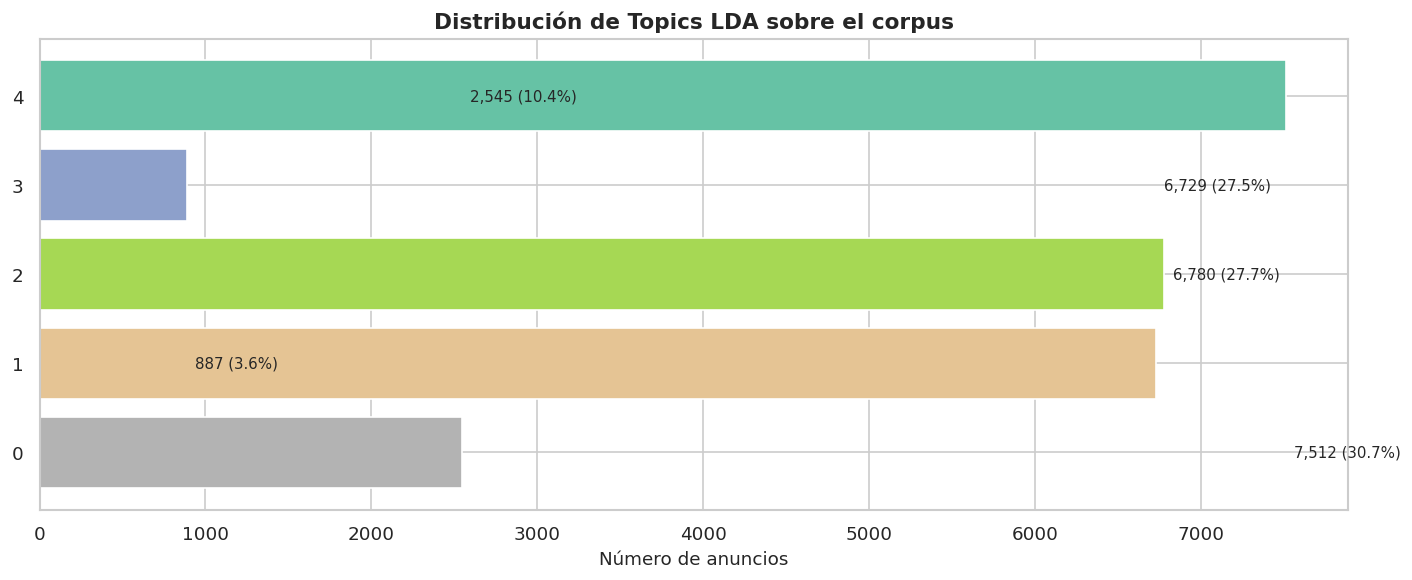

In [11]:
# ── Asignar topic dominante ────────────────────────────────────────────
# IMPORTANTE: revisar los nombres de TOPIC_NAMES tras inspeccionar la celda anterior.
# Ajustar este diccionario manualmente según las top-palabras observadas.
# METER SEMILLA PARA SER DETERMINISTA EN LA ASIGNACIÓN DE TOPICS (doc_topic_matrix.argmax)
TOPIC_NAMES = {i: f"Topic {i}" for i in range(K_FINAL)}  # ← ajustar manualmente

df_c['topic_id']    = doc_topic_matrix.argmax(axis=1)
df_c['topic_label'] = df_c['topic_id'].map(TOPIC_NAMES)
df_c['topic_score'] = doc_topic_matrix.max(axis=1)
df_c['topic_vector'] = [json.dumps(v.round(3).tolist()) for v in doc_topic_matrix]

# Vectores por columna para Feature Store
for i in range(K_FINAL):
    df_c[f'topic_{i}_prob'] = doc_topic_matrix[:, i]

# ── Distribución global de topics ─────────────────────────────────────
dist   = df_c['topic_id'].value_counts().sort_index()
colors = plt.cm.Set2(np.linspace(0, 1, len(dist)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(dist.index[::-1], dist.values[::-1], color=colors)
ax.set_title('Distribución de Topics LDA sobre el corpus')
ax.set_xlabel('Número de anuncios')
for j, v in enumerate(dist.values[::-1]):
    ax.text(v + 50, j, f'{v:,} ({v/len(df_c)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('IMG/plot_lda_distribucion.png', bbox_inches='tight')
plt.show()


## 5. Extracción de Features Regex

Features binarias derivadas de los patrones léxicos identificados en el análisis
TF-IDF / LDA. Cada patrón ha sido validado empíricamente sobre el corpus.

In [12]:
# ── Patrones regex derivados del análisis TF-IDF / LDA ─────────────────
PATTERNS = {
    # ITV
    'itv_vigente'      : r'itv.{0,20}(pasada|vigor|vigente|recién|recien|válida|valida|nueva|20[2-3]\d)',
    'itv_caducada'     : r'(sin itv|itv caducad|itv.*vencid)',

    # Mantenimiento
    'distribucion'     : r'(distribución|distribucion|correa distribución|cadena distribución)',
    'aceite_cambiado'  : r'(aceite.{0,15}(cambiado|nuevo|recién|recien)|cambio.{0,10}aceite)',
    'embrague_cambiado': r'(embrague.{0,15}(nuevo|cambiado|recién|recien)|cambio.{0,10}embrague)',
    'revision_reciente': r'(revisado|revisión.{0,10}(reciente|recién|completa)|puesto.{0,10}punto)',

    # Averías declaradas
    'averia_declarada' : r'(no arranca|no enciende|avería|averia|no funciona|falla|fallo'
                         r'|problema.{0,15}(motor|frenos|caja|cambio)'
                         r'|necesita.{0,15}(reparar|cambiar|arreglar))',
    'golpe_dano'       : r'(golpe|rayón|rayon|abolladura|rozadura|daño estético|accidente.{0,10}leve)',

    # Precio / negociación
    'precio_negociable': r'(precio.{0,10}negociable|negociable|a tratar|precio a convenir|hacer oferta)',
    'no_acepta_cambio' : r'(no acepto cambio|no se acepta cambio|sin cambio)',

    # Tipo de vendedor
    'particular'       : r'\bparticular\b',
    'concesionario'    : r'(concesionario|autohero|heycar|carnext|coches\.com|grupo.{0,15}auto'
                         r'|taller oficial|red oficial)',

    # Documentación
    'un_propietario'   : r'(único.{0,10}(dueño|propietario)|un (solo |único )?propietario|primer dueño)',
    'libro_revisiones' : r'(libro.{0,10}(revisiones|mantenimiento|sellos)|revisiones.{0,10}(oficial|dealer))',
    'garantia_oficial' : r'(garantía.{0,10}(oficial|concesionario|marca)|garantía.{0,5}\d+.{0,5}meses)',
    'nacional'         : r'\bnacional\b',

    # Neumáticos
    'neumaticos_nuevos': r'(neumático.{0,10}nuevo|neumatico.{0,10}nuevo|gomas.{0,10}nueva|ruedas.{0,10}nueva)',

    # Color
    'color_blanco'     : r'\bblanco\b',
    'color_negro'      : r'\bnegro\b',
    'color_gris'       : r'\bgris\b',
    'color_rojo'       : r'\brojo\b',
    'color_azul'       : r'\bazul\b',
    'color_plata'      : r'\b(plata|plateado|silver)\b',

    # Equipamiento
    'techo_solar'      : r'(techo.{0,10}(solar|panorámic|panoramic|abre)|panorámica)',
    'cuero'            : r'\b(cuero|piel)\b',
    'navegador'        : r'(navegador|gps|navi|navegación)',
    'camara_trasera'   : r'(cámara.{0,10}(trasera|marcha atrás)|camara trasera)',
}

print(f"Total features regex definidas: {len(PATTERNS)}")
 
#HACER PRUEBAS COMPARATIVAS CON UN LLM

Total features regex definidas: 27


In [13]:
# ── Aplicar patrones ───────────────────────────────────────────────────
def extract_features(text: str) -> dict:
    if pd.isna(text) or not str(text).strip():
        return {k: False for k in PATTERNS} | {'itv_year_extracted': None,
                                                 'comment_length': 0,
                                                 'comment_words': 0}
    t      = str(text).lower()
    result = {k: bool(re.search(v, t)) for k, v in PATTERNS.items()}
    m      = re.search(r'itv.{0,20}(20\d{2})', t)
    result['itv_year_extracted'] = int(m.group(1)) if m else None
    result['comment_length']     = len(text)
    result['comment_words']      = len(text.split())
    return result

features_df = df_c['comments'].apply(lambda x: pd.Series(extract_features(x)))
features_df.index = df_c.index
print(f"Dimensiones features: {features_df.shape}")


Dimensiones features: (24453, 30)


                   anuncios     %
concesionario          6776  27.7
navegador              5116  20.9
cuero                  4934  20.2
revision_reciente      4465  18.3
nacional               4116  16.8
itv_vigente            3394  13.9
camara_trasera         3048  12.5
garantia_oficial       2503  10.2
color_negro            2406   9.8
techo_solar            2236   9.1
un_propietario         1542   6.3
distribucion           1528   6.2
golpe_dano             1377   5.6
color_gris             1167   4.8
precio_negociable       987   4.0
aceite_cambiado         923   3.8
libro_revisiones        892   3.6
neumaticos_nuevos       879   3.6
particular              860   3.5
color_blanco            856   3.5
averia_declarada        752   3.1
color_rojo              481   2.0
color_azul              442   1.8
color_plata             440   1.8
embrague_cambiado       339   1.4
itv_caducada             54   0.2
no_acepta_cambio         38   0.2


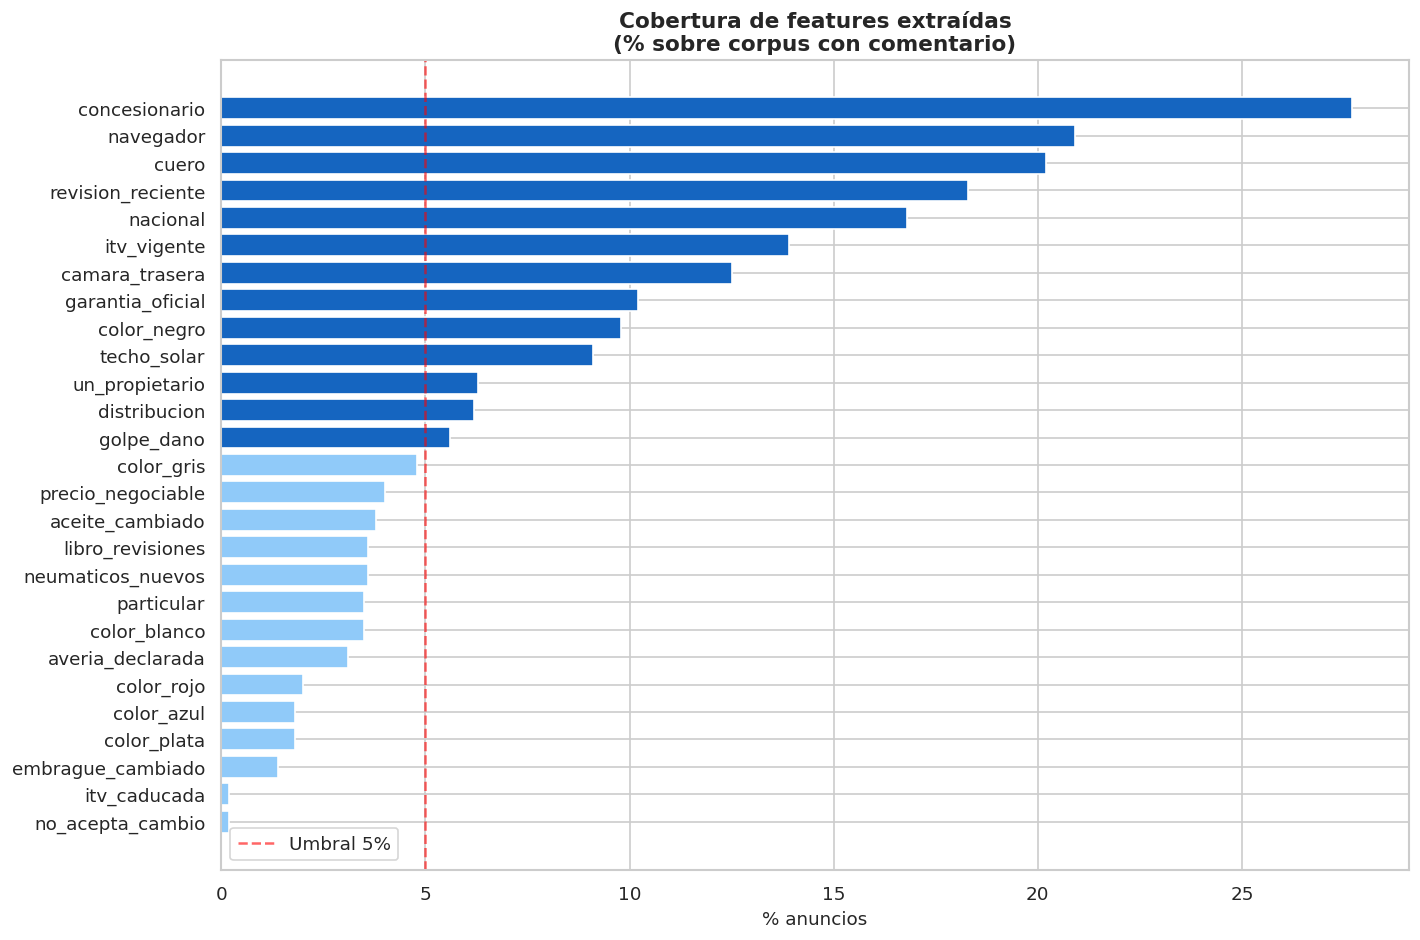

In [14]:
# ── Cobertura global ───────────────────────────────────────────────────
bool_cols = [c for c in features_df.columns if features_df[c].dtype == bool]
cov       = features_df[bool_cols].sum().sort_values(ascending=False)
cov_pct   = (cov / len(features_df) * 100).round(1)

print(pd.DataFrame({'anuncios': cov, '%': cov_pct}).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = ['#1565C0' if v > 5 else '#90CAF9' for v in cov_pct.values]
ax.barh(cov_pct.index[::-1], cov_pct.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(5, color='red', linestyle='--', alpha=0.6, label='Umbral 5%')
ax.set_title('Cobertura de features extraídas\n(% sobre corpus con comentario)')
ax.set_xlabel('% anuncios')
ax.legend()
plt.tight_layout()
plt.savefig('IMG/plot_features_cobertura.png', bbox_inches='tight')
plt.show()


### 5.1 Cobertura de features por segmento

¿Algunos indicadores de calidad son significativamente más frecuentes en Plus/Premium?
Este análisis revela diferencias estructurales en el comportamiento de los vendedores
por segmento de mercado.

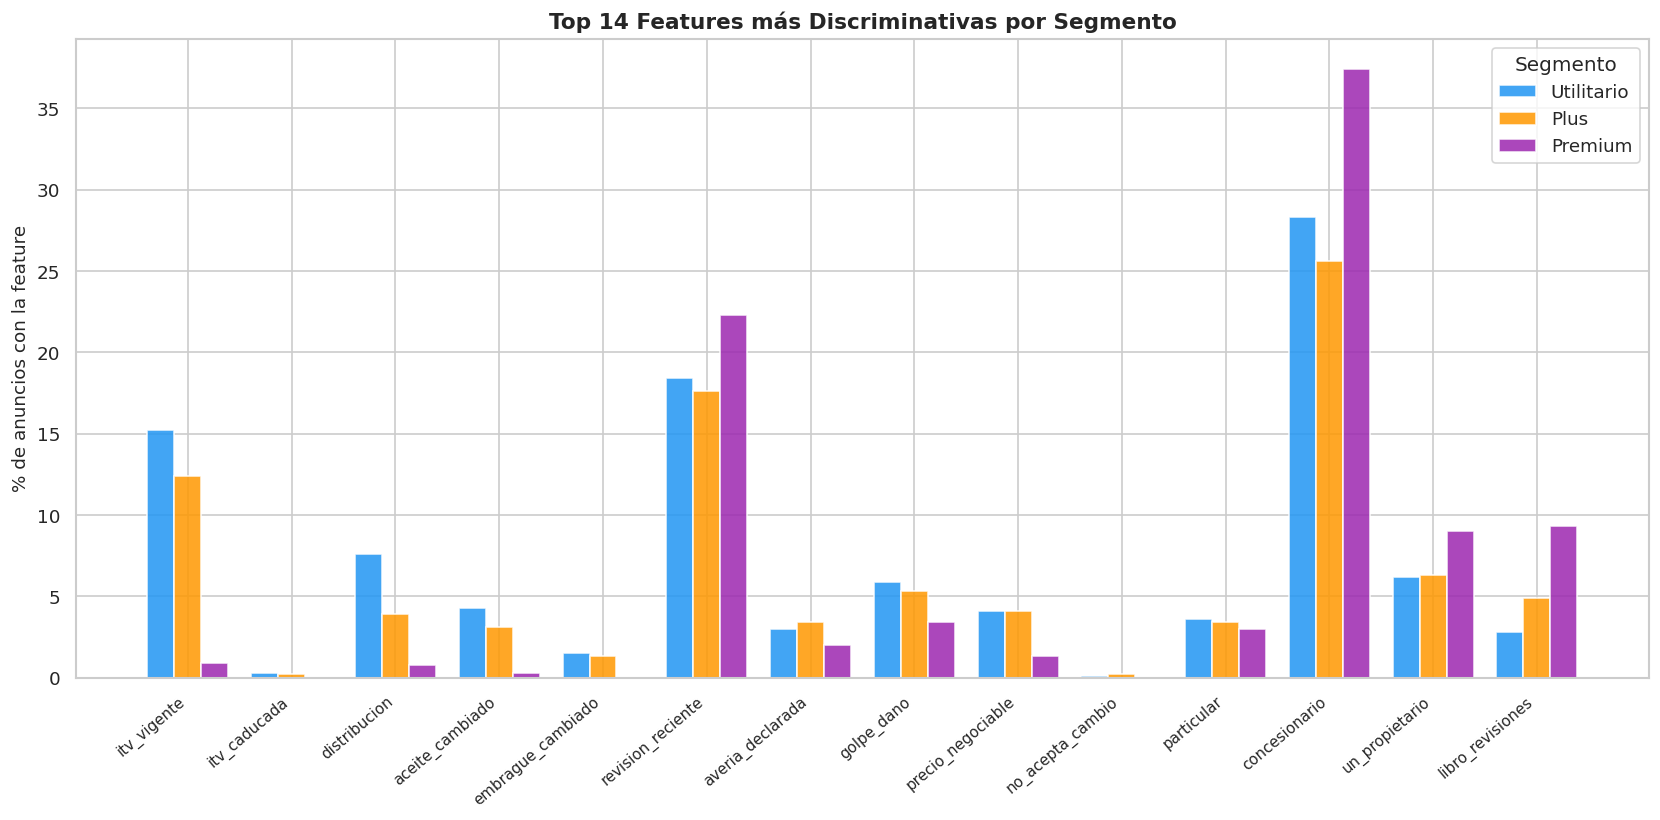


Top 5 features con mayor variación entre segmentos:
segmento           Utilitario  Plus  Premium
itv_vigente              15.2  12.4      0.9
itv_caducada              0.3   0.2      0.0
distribucion              7.6   3.9      0.8
aceite_cambiado           4.3   3.1      0.3
embrague_cambiado         1.5   1.3      0.0


In [15]:
# ── Features por segmento ─────────────────────────────────────────────
# Justificación NUEVA: features como 'garantia_oficial', 'libro_revisiones'
# y 'un_propietario' deben concentrarse en Plus/Premium si la hipótesis de
# que el segmento se refleja en el lenguaje de venta es correcta.
df_feat_seg = df_c[['segmento']].join(features_df[bool_cols])

seg_cov = df_feat_seg.groupby('segmento')[bool_cols].mean().mul(100).round(1).loc[SEG_ORDER]

# Seleccionar las features más discriminativas (mayor varianza entre segmentos)
seg_cov['std'] = seg_cov.std(axis=0, skipna=True)
top_feats = seg_cov.drop(columns='std').T.assign(
    var=seg_cov['std']
).sort_values('var', ascending=False).head(14).index.tolist()
seg_cov = seg_cov.drop(columns='std')

fig, ax = plt.subplots(figsize=(14, 7))
x      = np.arange(len(top_feats))
width  = 0.26
for i, seg in enumerate(SEG_ORDER):
    vals = seg_cov.loc[seg, top_feats].values
    bars = ax.bar(x + i*width, vals, width, label=seg,
                  color=SEG_COLORS[seg], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(top_feats, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('% de anuncios con la feature')
ax.set_title('Top 14 Features más Discriminativas por Segmento')
ax.legend(title='Segmento')
plt.tight_layout()
plt.savefig('IMG/plot_features_segmento.png', bbox_inches='tight')
plt.show()

# Tabla de las top 5 más discriminativas
print("\nTop 5 features con mayor variación entre segmentos:")
print(seg_cov[top_feats[:5]].T.to_string())


## 6. Impacto de las Features en el Precio

Análisis del precio mediano según la presencia o ausencia de cada feature clave,
desglosado por segmento. Una feature valiosa es aquella donde la diferencia de precio
entre `True` y `False` es consistente y estadísticamente razonable.

In [16]:
# ── Merge features + precio ─────────────────────────────────────────────
enriched_price = df_c[['id', 'segmento', 'price']].join(features_df[bool_cols])

FEATURES_ANALISIS = [
    'revision_reciente', 'un_propietario', 'garantia_oficial',
    'libro_revisiones',  'particular',     'concesionario',
    'precio_negociable', 'averia_declarada','itv_vigente',
    'techo_solar',       'cuero',           'neumaticos_nuevos',
]
FEATURES_ANALISIS = [f for f in FEATURES_ANALISIS if f in bool_cols]

print(f"{'Feature':<25} {'Seg':>12} {'Con (True)':>11} {'Sin (False)':>12} {'Δ precio':>10}")
print("-"*72)
for feat in FEATURES_ANALISIS:
    for seg in SEG_ORDER:
        sub = enriched_price[enriched_price['segmento'] == seg]
        if sub[feat].sum() < 10:
            continue
        p_true  = sub[sub[feat]]['price'].median()
        p_false = sub[~sub[feat]]['price'].median()
        delta   = p_true - p_false
        print(f"{feat:<25} {seg:>12} {p_true:>10,.0f}€  {p_false:>11,.0f}€  {delta:>+9,.0f}€")
    print()


Feature                            Seg  Con (True)  Sin (False)   Δ precio
------------------------------------------------------------------------
revision_reciente           Utilitario     15,500€       12,725€     +2,775€
revision_reciente                 Plus     24,490€       21,495€     +2,995€
revision_reciente              Premium     74,800€       78,945€     -4,145€

un_propietario              Utilitario     13,894€       13,099€       +796€
un_propietario                    Plus     23,990€       21,990€     +2,000€
un_propietario                 Premium     74,900€       77,945€     -3,045€

garantia_oficial            Utilitario     16,990€       12,800€     +4,190€
garantia_oficial                  Plus     29,900€       21,400€     +8,500€
garantia_oficial               Premium     82,400€       75,900€     +6,500€

libro_revisiones            Utilitario     13,999€       13,100€       +899€
libro_revisiones                  Plus     25,000€       21,990€     +3,010€
li

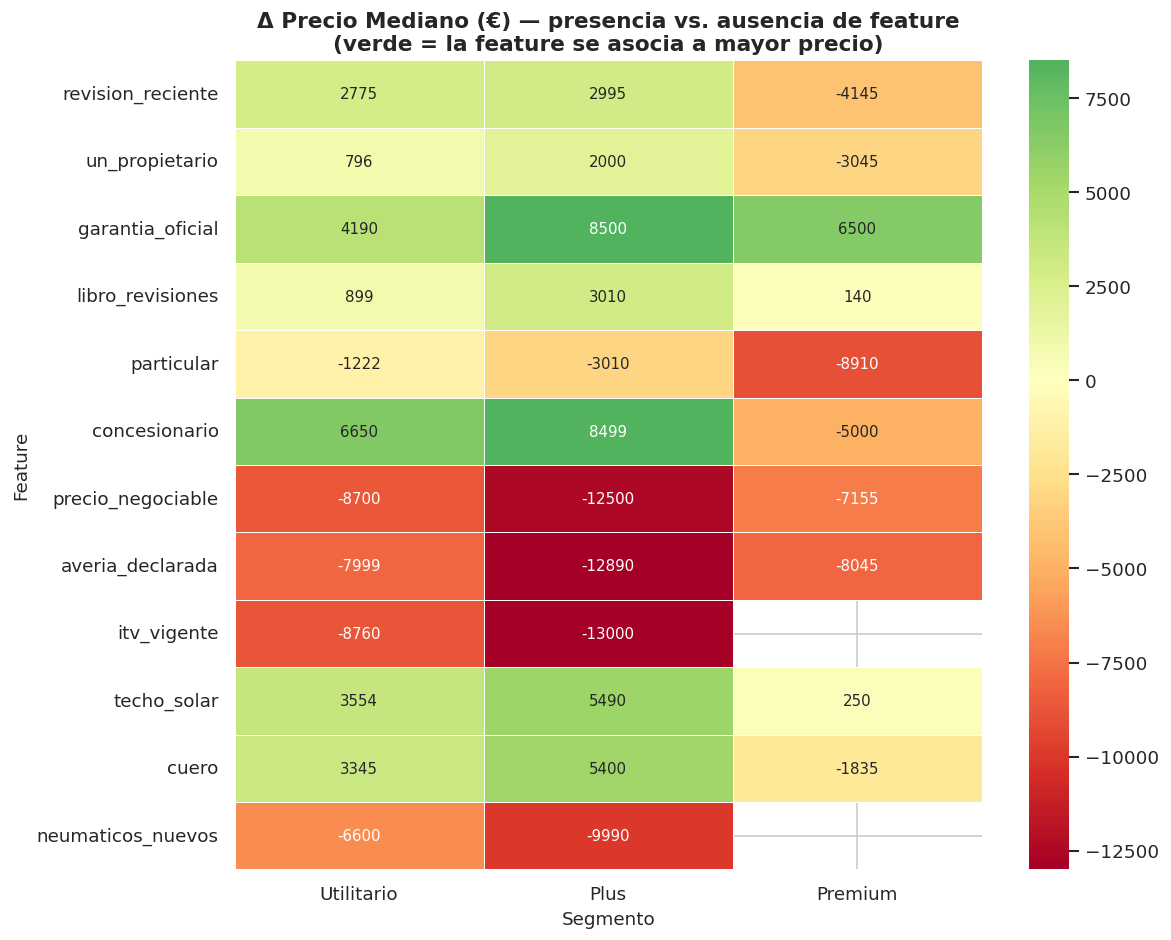

In [17]:
# ── Heatmap: Δprecio mediano (True - False) por feature × segmento ─────
delta_data = {}
for feat in FEATURES_ANALISIS:
    deltas = {}
    for seg in SEG_ORDER:
        sub = enriched_price[enriched_price['segmento'] == seg]
        if sub[feat].sum() < 10:
            deltas[seg] = np.nan
            continue
        deltas[seg] = sub[sub[feat]]['price'].median() - sub[~sub[feat]]['price'].median()
    delta_data[feat] = deltas

delta_df = pd.DataFrame(delta_data).T[SEG_ORDER]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(delta_df, annot=True, fmt='.0f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Δ Precio Mediano (€) — presencia vs. ausencia de feature\n(verde = la feature se asocia a mayor precio)')
ax.set_xlabel('Segmento'); ax.set_ylabel('Feature')
#ax.set_border(True)
plt.tight_layout()
plt.savefig('IMG/plot_features_precio_delta.png', bbox_inches='tight')
plt.show()


## 7. Integración y Exportación del Feature Store

Consolidación de todas las features en `comments_features.csv`, listo para cargarse
en Snowflake como `stg_comment_features` y unirse con `stg_ml_features` en la capa dbt.

In [18]:
# ── Construir dataset enriquecido ──────────────────────────────────────
topic_cols_export = ['topic_id', 'topic_label', 'topic_score', 'topic_vector']
topic_prob_cols   = [f'topic_{i}_prob' for i in range(K_FINAL)]

enriched = (
    df_c[['id']]
    .join(features_df)
    .join(df_c[topic_cols_export + topic_prob_cols])
)

enriched.to_csv('comments_features.csv', index=False)

print(f"Dataset exportado : comments_features.csv")
print(f"Filas             : {len(enriched):,}")
print(f"Columnas          : {len(enriched.columns):,}")
print(f"  → Features bool : {len(bool_cols)}")
print(f"  → Topic probs   : {K_FINAL}")
print(f"  → Otros         : {len(enriched.columns) - len(bool_cols) - K_FINAL}")
print(f"\nNulos totales     : {enriched.isnull().sum().sum()}")
enriched.head(3)


Dataset exportado : comments_features.csv
Filas             : 24,453
Columnas          : 40
  → Features bool : 27
  → Topic probs   : 5
  → Otros         : 8

Nulos totales     : 23474


,id,itv_vigente,itv_caducada,distribucion,aceite_cambiado,embrague_cambiado,revision_reciente,averia_declarada,golpe_dano,precio_negociable,...,comment_words,topic_id,topic_label,topic_score,topic_vector,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob
0,62479826,False,False,False,False,False,False,False,False,False,...,100,4,Topic 4,0.660111,"[0.004, 0.004, 0.327, 0.004, 0.66]",0.004446,0.004446,0.326552,0.004445,0.660111
1,62595348,False,False,False,False,False,True,True,True,False,...,146,4,Topic 4,0.906741,"[0.004, 0.082, 0.004, 0.004, 0.907]",0.003774,0.081936,0.003774,0.003774,0.906741
2,62646888,True,False,True,False,False,False,False,False,False,...,17,4,Topic 4,0.733345,"[0.018, 0.212, 0.018, 0.018, 0.733]",0.018182,0.212107,0.018185,0.018182,0.733345


## Resumen de decisiones

| Paso | Qué se hizo | Por qué |
|------|-------------|---------|
| Merge con anuncios.csv | Unión por `id` para incorporar segmento y precio | Habilita todo el análisis diferencial por segmento |
| Stopwords dominio | Lista curada sin NLTK | Evita dependencias externas; incluye términos genéricos de coches |
| TF-IDF global | `max_features=300`, bigramas, `min_df=15`, `max_df=0.85` | Filtra hápax y términos omnipresentes; bigramas capturan expresiones clave |
| TF-IDF diferencial | Vectorizador independiente por segmento | Revela vocabulario exclusivo de cada nivel de mercado |
| LDA | K seleccionado por curva de perplexity | Objetiva la elección de K; mejor que un valor arbitrario |
| Topic names | Diccionario manual (`TOPIC_NAMES`) | LDA no garantiza orden entre ejecuciones; la asignación debe ser manual |
| Features regex | Patrones derivados de TF-IDF/LDA | Convierte lenguaje libre en variables binarias para el Feature Store |
| Análisis por segmento | Cobertura y Δprecio por Utilitario/Plus/Premium | Valida si las features son discriminativas entre segmentos |
| Export | `comments_features.csv` → `stg_comment_features` | Interfaz entre el módulo NLP y la capa dbt/Snowflake |

**Archivos de entrada:** `comments.csv`, `anuncios.csv`  
**Archivos de salida:** `comments_features.csv`, `IMG/*.png`